# 10.5.1 VARMA 모델을 사용해 realdpi와 realcons 예측

In [2]:
# Import libraries
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.varmax import VARMAX
from tqdm import tqdm_notebook
from itertools import product

import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [6]:
macro_econ_data = sm.datasets.macrodata.load_pandas().data
macro_econ_data.tail()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19
202,2009.0,3.0,12990.341,9256.0,1486.398,1044.088,10040.6,216.385,1673.9,0.12,9.6,308.013,3.56,-3.44


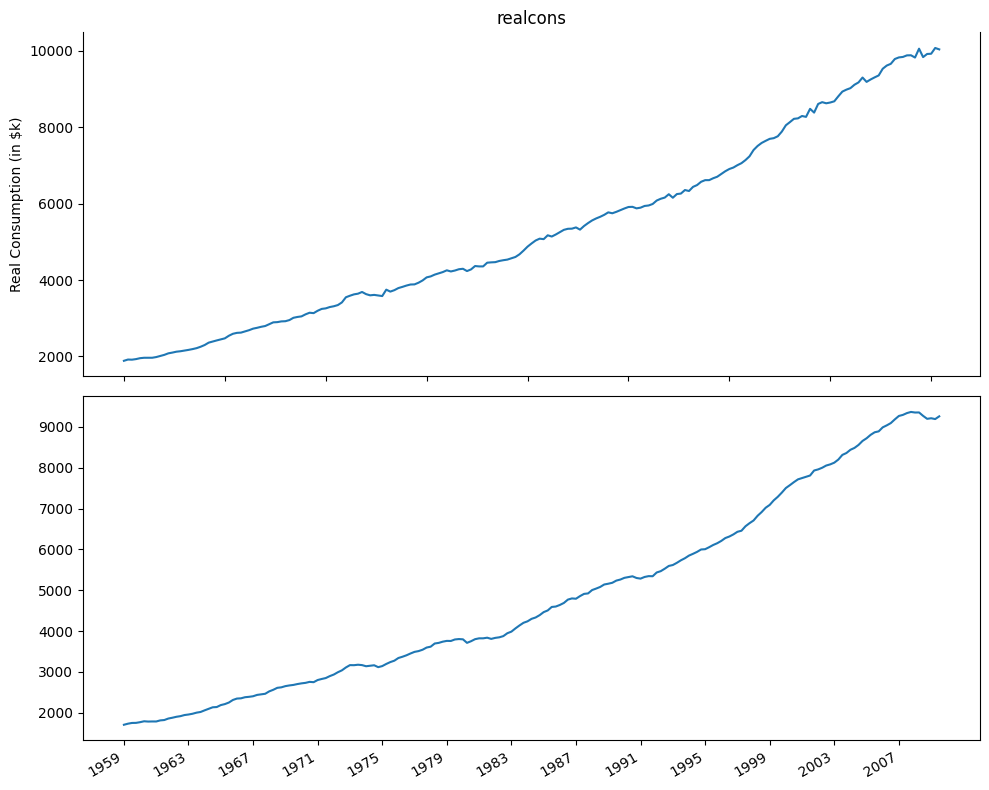

In [8]:
fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, figsize = (10, 8))

ax1.plot(macro_econ_data['realdpi'])
ax1.set_xlabel('Date')
ax1.set_ylabel('Real DPI (in $k)')
ax1.set_title('realdpi')
ax1.spines['top'].set_alpha(0)

ax2.plot(macro_econ_data['realcons'])
ax1.set_xlabel('Date')
ax1.set_ylabel('Real Consumption (in $k)')
ax1.set_title('realcons')
ax1.spines['top'].set_alpha(0)

plt.xticks(np.arange(0, 208, 16), np.arange(1959, 2010, 4))
#208: quarter count (1959-2010 has 208 quarters)

fig.autofmt_xdate()
plt.tight_layout()

In [9]:
# check stationary
ad_fuller_result_1 = adfuller(macro_econ_data['realdpi'])

print('realdpi')
print(f'ADF Stats: {ad_fuller_result_1[0]}')
print(f'ADF p-val: {ad_fuller_result_1[1]}')

print('\n--------------------\n')

ad_fuller_result_2 = adfuller(macro_econ_data['realcons'])

print('realcons')
print(f'ADF Stats: {ad_fuller_result_2[0]}')
print(f'ADF p-val: {ad_fuller_result_2[1]}')


realdpi
ADF Stats: 2.9860253519546864
ADF p-val: 1.0

--------------------

realcons
ADF Stats: 1.5499123380509636
ADF p-val: 0.9976992503412904


In [10]:
# not stationary; differencing

ad_fuller_result_1 = adfuller(macro_econ_data['realdpi'].diff()[1:])

print('realdpi')
print(f'ADF Stats: {ad_fuller_result_1[0]}')
print(f'ADF p-val: {ad_fuller_result_1[1]}')

print('\n--------------------\n')

ad_fuller_result_2 = adfuller(macro_econ_data['realcons'].diff()[1:])

print('realcons')
print(f'ADF Stats: {ad_fuller_result_2[0]}')
print(f'ADF p-val: {ad_fuller_result_2[1]}')

realdpi
ADF Stats: -8.864893340673008
ADF p-val: 1.449360615910809e-14

--------------------

realcons
ADF Stats: -4.204306080845247
ADF p-val: 0.000647928215862757


In [11]:
# now stationary; start modeling

def optimize_VARMA(endog, parameters_list):
    results = []

    for param in tqdm_notebook(parameters_list):
        try:
            model = VARMAX(endog, order = param).fit(disp = False)
        except:
            continue

        aic = model.aic
        results.append([param, aic])

    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']

    result_df = result_df.sort_values(by = 'AIC', ascending = True).reset_index(drop = True)

    return result_df

In [12]:
# define the range of (p,q)

endog = macro_econ_data[['realdpi', 'realcons']]

#use differenced version
endog_diff = macro_econ_data[['realdpi', 'realcons']].diff()[1:]

train = endog_diff[:162]
test = endog_diff[162:]

p = range(0, 4, 1)
q = range(0, 4, 1)
# 왜 0~3? --> 관행. 

parameters = product(p,q)
parameters_list = list(parameters)

result_df_VARMA = optimize_VARMA(train, parameters_list)
result_df_VARMA


  0%|          | 0/16 [00:00<?, ?it/s]

,"(p,q)",AIC
0,"(3, 0)",3123.070079
1,"(2, 1)",3124.094108
2,"(1, 3)",3125.126814
3,"(3, 2)",3125.424867
4,"(2, 3)",3125.733204
5,"(1, 2)",3126.931519
6,"(3, 1)",3129.008390
7,"(1, 1)",3129.650909
8,"(2, 2)",3129.937826
9,"(2, 0)",3130.091668


In [13]:
# so choose p = 3, q = 0
# now do Granger Causality Test

print('realcons Granger Test to realdpi')
granger_1 = grangercausalitytests(macro_econ_data[['realdpi', 'realcons']].diff()[1:], [3])

print('\nrealdpi Granger Test to realcons')
granger_2 = grangercausalitytests(macro_econ_data[['realcons', 'realdpi']].diff()[1:], [3])

realcons Granger Test to realdpi

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=28.7191 , p=0.0000  , df=3
likelihood ratio test: chi2=26.8268 , p=0.0000  , df=3
parameter F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3

realdpi Granger Test to realcons

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=8.7625  , p=0.0326  , df=3
likelihood ratio test: chi2=8.5751  , p=0.0355  , df=3
parameter F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3


In [14]:
# all below 0.05: reject the null

best_model = VARMAX(train, order = (3,0))
best_model_fit = best_model.fit(disp = False)

print(best_model_fit.summary())

                              Statespace Model Results                             
Dep. Variable:     ['realdpi', 'realcons']   No. Observations:                  162
Model:                              VAR(3)   Log Likelihood               -1544.535
                               + intercept   AIC                           3123.070
Date:                     Sat, 19 Sep 2026   BIC                           3175.559
Time:                             15:18:10   HQIC                          3144.381
Sample:                                  0                                         
                                     - 162                                         
Covariance Type:                       opg                                         
Ljung-Box (L1) (Q):             0.01, 0.03   Jarque-Bera (JB):          43.86, 4.35
Prob(Q):                        0.91, 0.87   Prob(JB):                   0.00, 0.11
Heteroskedasticity (H):         4.44, 3.59   Skew:                      0.14